# Resultado calificación total del modelo CAMEL

Para obtener la calificación total (usando todos los indicadores previamente calculados) se tienen los siguientes pasos:

1. Descarga y lectura de los datos (Resultado de calificación individual de los indicadores).
2. Extracción y valoración del PCA.
3. Creación de los rangos (percentiles para las variables).
4. Calificación modelo CAMEL - general.
5. Calificación modelo CAMEL - sectorizado

# 1. Extracción de datos

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

In [2]:
datos=pd.read_csv("Registros_CAMEL_sin_solvencia_categorizados.csv")
datos.head()

,ID_registro,ano,mes,ID_indicador,ID_cooperativa,valor,categoria
0,1,2022,1,Quebranto Patrimonial,AVANCOP COOPERATIVA DE AHORRO Y CREDITO,1.265719,Micro 1
1,3,2022,1,Relación entre Aportes sociales mínimos no red...,AVANCOP COOPERATIVA DE AHORRO Y CREDITO,0.431216,Micro 1
2,4,2022,1,Relación entre el Capital Institucional y el A...,AVANCOP COOPERATIVA DE AHORRO Y CREDITO,0.067410,Micro 1
3,5,2022,2,Quebranto Patrimonial,AVANCOP COOPERATIVA DE AHORRO Y CREDITO,1.270411,Micro 1
4,7,2022,2,Relación entre Aportes sociales mínimos no red...,AVANCOP COOPERATIVA DE AHORRO Y CREDITO,0.430248,Micro 1


In [ ]:
# en la columna "valor" cambiar nulos por o
datos["valor"] = datos["valor"].fillna(0)
#cuando el valor de la columna "valor" sea ' ', cambiarlo por 0
datos["valor"] = datos["valor"].replace(' ', 0)
#cambiar el tipo de dato de la columna "valor" a float
datos["valor"] = datos["valor"].astype(float)
#cambia top 4
datos.loc[datos["categoria"] == "Top 4", "categoria"] = "Megas"
#'Micro 1', 'Medianas', 'Megas', 'Pequeñas', 'Grandes', 'Micro 2','Top 4'

In [4]:
datos["ID_indicador"].unique()

array(['Quebranto Patrimonial',
       'Relación entre Aportes sociales mínimos no reducibles y Capital Social',
       'Relación entre el Capital Institucional y el Activo Total',
       'Indicador de calidad por riesgo',
       'Indicador de calidad por riesgo con castigos',
       'Activo Productivo',
       'Indicador de Cobertura de la Cartera Total en Riesgo',
       'Indicador de Cobertura individual de la cartera improductiva para la cartera en Riesgo',
       'Estructura de Balance',
       'Indicador de Margen Financiero de Operación',
       'Indicador de Margen Operacional',
       'Indicador de relación entre las obligaciones financieras y el pasivo total',
       'Indicador de margen neto',
       'Indicador de rentabilidad sobre el capital invertido - ROIC',
       'Indicador de rentabilidad sobre recursos propios - ROE',
       'Indicador de Riesgo de Liquidez - IRL'], dtype=object)

# 2. Cálculo PCA

In [5]:
def pesos_pca_grupo_coops(
    df,
    lista_coops,
    col_nombre="ID_cooperativa",
    n_componentes=3
):
    
    # filtrar cooperativas
    df_filtrado = df[df[col_nombre].isin(lista_coops)].copy()
    
    if df_filtrado.empty:
        raise ValueError("No hay datos para las cooperativas indicadas")
    
    # LIMPIEZA 
    df_filtrado["valor"] = (
        df_filtrado["valor"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    
    df_filtrado["valor"] = pd.to_numeric(df_filtrado["valor"], errors="coerce")
    
    # pivot (matriz indicadores)
    df_pivot = df_filtrado.pivot_table(
        index=col_nombre,
        columns="ID_indicador",
        values="valor",
        aggfunc="mean"
    )
    
    # imputar faltantes
    imputer = SimpleImputer(strategy="mean")
    X_imputed = imputer.fit_transform(df_pivot)
    
    # escalar
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)
    
    # PCA
    pca = PCA(n_components=min(n_componentes, df_pivot.shape[1]))
    pca.fit(X_scaled)
    
    loadings = pd.DataFrame(
        pca.components_.T,
        index=df_pivot.columns
    )
    
    pesos = (loadings**2).mean(axis=1)
    
    # porcentaje
    pesos = (pesos / pesos.sum()) 
    
    return pesos.sort_values(ascending=False)

# 3. Cálculo Rangos

In [6]:
INDICADORES_INVERSOS = [
    "Indicador de calidad por riesgo",
    "Indicador de calidad por riesgo con castigos",
    "Indicador de Cobertura de la Cartera Total en Riesgo",
    "Indicador de relación entre las obligaciones financieras y el pasivo total",
    "Indicador de Margen Financiero de Operación",
    "Indicador de Margen Operacional"
]

INDICADOR_SOLVENCIA = "Relación Solvencia"
INDICADOR_IRL = "IRL"

PERCENTILES = [20, 40, 60, 80]


# ======================================================
# CALCULAR PERCENTILES
# ======================================================

def calcular_percentiles(df, indicadores):

    resultados = {}

    primer_corte = PERCENTILES[0]          # 20
    cortes_restantes = PERCENTILES[1:]     # [40, 60, 80]

    for indicador in indicadores:

        subset = df[df["ID_indicador"] == indicador].copy()

        if subset.empty:
            continue

        valores = subset["valor"].dropna()

        # ----------------------------------
        # IRL → aplicar log10(x)
        # ----------------------------------
        if indicador== INDICADOR_IRL:

            valores = valores[valores > 0]

            if len(valores) == 0:
                continue

            valores = np.log10(valores)

        # ----------------------------------
        # Detectar muchos ceros
        # ----------------------------------
        porcentaje_ceros = (valores == 0).mean()

        if porcentaje_ceros >= 0.10:

            valores_sin_cero = valores[valores > 0]

            p = {}

            # Primer corte = 0
            p[primer_corte] = 0

            if len(valores_sin_cero) > 0:

                for q in cortes_restantes:

                    q_ajustado = (q - primer_corte) / (100 - primer_corte)

                    p[q] = valores_sin_cero.quantile(q_ajustado)

            else:

                for q in cortes_restantes:
                    p[q] = 0

        else:

            p = {
                q: valores.quantile(q / 100)
                for q in PERCENTILES
            }

        # ----------------------------------
        # Relación solvencia → primer corte = 9
        # ----------------------------------
        if indicador == INDICADOR_SOLVENCIA:

            p[primer_corte] = 9

            for q in cortes_restantes:

                p[q] = max(
                    p[q],
                    p[primer_corte]
                )

        resultados[indicador] = p

    return resultados

# ======================================================
# ASIGNAR CALIFICACIÓN
# ======================================================

def asignar_calificacion(valor, cortes, inverso=False):

    limites = sorted(cortes.items())

    if not inverso:

        for i, (_, limite) in enumerate(limites):

            if valor <= limite:
                return i + 1

        return 5

    else:

        limites_valores = [x[1] for x in limites]

        for i, limite in enumerate(reversed(limites_valores)):

            if valor >= limite:
                return i + 1

        return 5


# ======================================================
# CALIFICAR DATAFRAME
# ======================================================

def calificar_dataframe(df):

    df = df.copy()

    indicadores = df["ID_indicador"].unique()

    percentiles = calcular_percentiles(
        df,
        indicadores
    )

    calificaciones = []

    for _, row in df.iterrows():

        indicador = row["ID_indicador"]

        valor = row["valor"]

        if pd.isna(valor):
            calificaciones.append(None)
            continue

        # -------------------------
        # IRL → aplicar log10
        # -------------------------
        if indicador == INDICADOR_IRL:

            if valor <= 0:
                calificaciones.append(None)
                continue

            valor = np.log10(valor)

        inverso = indicador in INDICADORES_INVERSOS

        nota = asignar_calificacion(
            valor=valor,
            cortes=percentiles[indicador],
            inverso=inverso
        )

        calificaciones.append(nota)

    df["calificacion"] = calificaciones

    return df, percentiles

In [7]:
def calcular_calificaciones_formato_lista(df: pd.DataFrame):

    if df.empty:
        return []

    columnas_necesarias = {
        'ID_indicador',
        'ID_cooperativa',
        'valor'
    }

    if not columnas_necesarias.issubset(df.columns):
        raise ValueError("Faltan columnas necesarias")

    df = df.copy()

    # ---------------------------------
    # Calcular percentiles (tu lógica)
    # ---------------------------------
    indicadores = df["ID_indicador"].unique()

    percentiles = calcular_percentiles(
        df,
        indicadores
    )

    resultados_temp = []

    # ---------------------------------
    # Calificar fila por fila
    # ---------------------------------
    for _, row in df.iterrows():

        indicador = row["ID_indicador"]
        cooperativa = row["ID_cooperativa"]
        valor = row["valor"]

        if pd.isna(valor):
            continue

        # IRL → log10
        if indicador == INDICADOR_IRL:

            if valor <= 0:
                continue

            valor = np.log10(valor)

        inverso = indicador in INDICADORES_INVERSOS

        calificacion = asignar_calificacion(
            valor=valor,
            cortes=percentiles[indicador],
            inverso=inverso
        )

        resultados_temp.append({
            "ID_cooperativa": str(cooperativa),
            "ID_indicador": str(indicador),
            "calificacion": int(calificacion)
        })

    # ---------------------------------
    # Promediar si una cooperativa
    # tiene varias filas del mismo indicador
    # ---------------------------------
    df_result = pd.DataFrame(resultados_temp)

    if df_result.empty:
        return []

    df_result = (
        df_result
        .groupby(
            ["ID_cooperativa", "ID_indicador"],
            as_index=False
        )["calificacion"]
        .mean()
        .round()
        .astype({
            "calificacion": int
        })
    )

    # ---------------------------------
    # Construir formato final
    # ---------------------------------
    resultado_final = {}

    for _, row in df_result.iterrows():

        coop = row["ID_cooperativa"]
        indicador = row["ID_indicador"]
        calificacion = row["calificacion"]

        if coop not in resultado_final:

            resultado_final[coop] = {
                "ID_cooperativa": coop,
                "calificaciones": {}
            }

        resultado_final[coop]["calificaciones"][
            indicador
        ] = calificacion
    df_result.to_excel("../../tablas/camel/Calificaciones_individuales_CAMEL.xlsx", index=False)
    return list(resultado_final.values())

In [8]:
calificaciones=calcular_calificaciones_formato_lista(datos)

In [9]:
df,percentiles=calificar_dataframe(datos)

In [10]:
percentiles_df = pd.DataFrame(percentiles).T
percentiles_df

,20,40,60,80
Quebranto Patrimonial,0.0,1.267154,1.403791,1.719225
Relación entre Aportes sociales mínimos no reducibles y Capital Social,0.0,0.488339,0.658402,0.817243
Relación entre el Capital Institucional y el Activo Total,0.0,0.057018,0.080551,0.115979
Indicador de calidad por riesgo,0.0,0.047890,0.069373,0.097683
Indicador de calidad por riesgo con castigos,0.0,0.007387,0.022990,0.054017
Activo Productivo,0.0,0.802521,0.862096,0.906043
Indicador de Cobertura de la Cartera Total en Riesgo,0.0,0.035941,0.054778,0.080657
Indicador de Cobertura individual de la cartera improductiva para la cartera en Riesgo,0.0,0.416283,0.559822,0.687617
Estructura de Balance,0.0,1.262333,1.471650,2.016463
Indicador de Margen Financiero de Operación,0.0,0.606643,0.714179,0.811473


# 4. Cálculo modelo CAMEL - general

In [11]:
lista_coops = datos["ID_cooperativa"].unique().tolist()
pca=pesos_pca_grupo_coops(
    datos,
    lista_coops=lista_coops,
    col_nombre="ID_cooperativa",
    n_componentes=3
)

In [12]:
pca_porcentaje=pca*100
pca_porcentaje

ID_indicador
Indicador de rentabilidad sobre recursos propios - ROE                                    15.275461
Indicador de rentabilidad sobre el capital invertido - ROIC                               13.837436
Indicador de margen neto                                                                   9.185208
Indicador de Margen Operacional                                                            8.827677
Indicador de calidad por riesgo                                                            5.946950
Indicador de Cobertura de la Cartera Total en Riesgo                                       5.742473
Indicador de Margen Financiero de Operación                                                5.352730
Estructura de Balance                                                                      4.831295
Activo Productivo                                                                          4.830568
Relación entre Aportes sociales mínimos no reducibles y Capital Social                 

In [16]:
def calcular_camel(lista, pesos):
    # Normalizar pesos
    pesos_norm = pesos / pesos.sum()
    
    resultados = []

    for coop in lista:
        nombre = coop["ID_cooperativa"]
        califs = coop["calificaciones"]

        score = 0

        for indicador, peso in pesos_norm.items():
            calificacion = califs.get(indicador, 0)  # si falta, toma 0
            score += calificacion * peso

        resultados.append({
            "ID_cooperativa": nombre,
            "CAMEL_score": score
        })

    return pd.DataFrame(resultados)

In [17]:
# Calcular CAMEL para todas las cooperativas
camel_definitivo = calcular_camel(calificaciones, pca)
camel_definitivo

,ID_cooperativa,CAMEL_score
0,AVANCOP COOPERATIVA DE AHORRO Y CREDITO,2.739003
1,CAJA COOPERATIVA CREDICOOP,2.330742
2,CAJA COOPERATIVA PETROLERA,2.657847
3,CASA NACIONAL DEL PROFESOR,2.835825
4,CESCA COOPERATIVA DE AHORRO Y CREDITO,3.032689
...,...,...
169,GRAN COOPERATIVA DE ENERGIA ELECTRICA Y RECURS...,3.721927
170,LA COOPERATIVA DE AHORRO Y CREDITO SUCREDITO,3.426719
171,MICROEMPRESAS DE COLOMBIA COOPERATIVA DE AHORR...,3.447690
172,ORGANIZACION COOPERATIVA DE AHORRO Y CREDITO N...,3.363601


In [18]:
camel_definitivo.sort_values(by="CAMEL_score",ascending=False)

,ID_cooperativa,CAMEL_score
124,COOPERATIVA LEON XIII LTDA DE GUATAPE,4.051976
166,FINANCIERA COOPERATIVA COLOMBIANA DE INGENIEROS,4.047662
30,COOPERATIVA DE AHORRO Y CREDITO DE EMPLEADOS D...,3.884557
101,COOPERATIVA DE YARUMAL,3.831572
29,COOPERATIVA DE AHORRO Y CREDITO DE DROGUISTAS ...,3.775941
...,...,...
82,COOPERATIVA DE LOS TRABAJADORES DE LA EDUCACIO...,1.977884
79,COOPERATIVA DE LA GUAJIRA LTDA,1.977884
75,COOPERATIVA DE EMPLEADOS DE LA UNIVERSIDAD TEC...,1.977884
148,COOPERATIVA PIO XLL DE COCORNA,1.977884


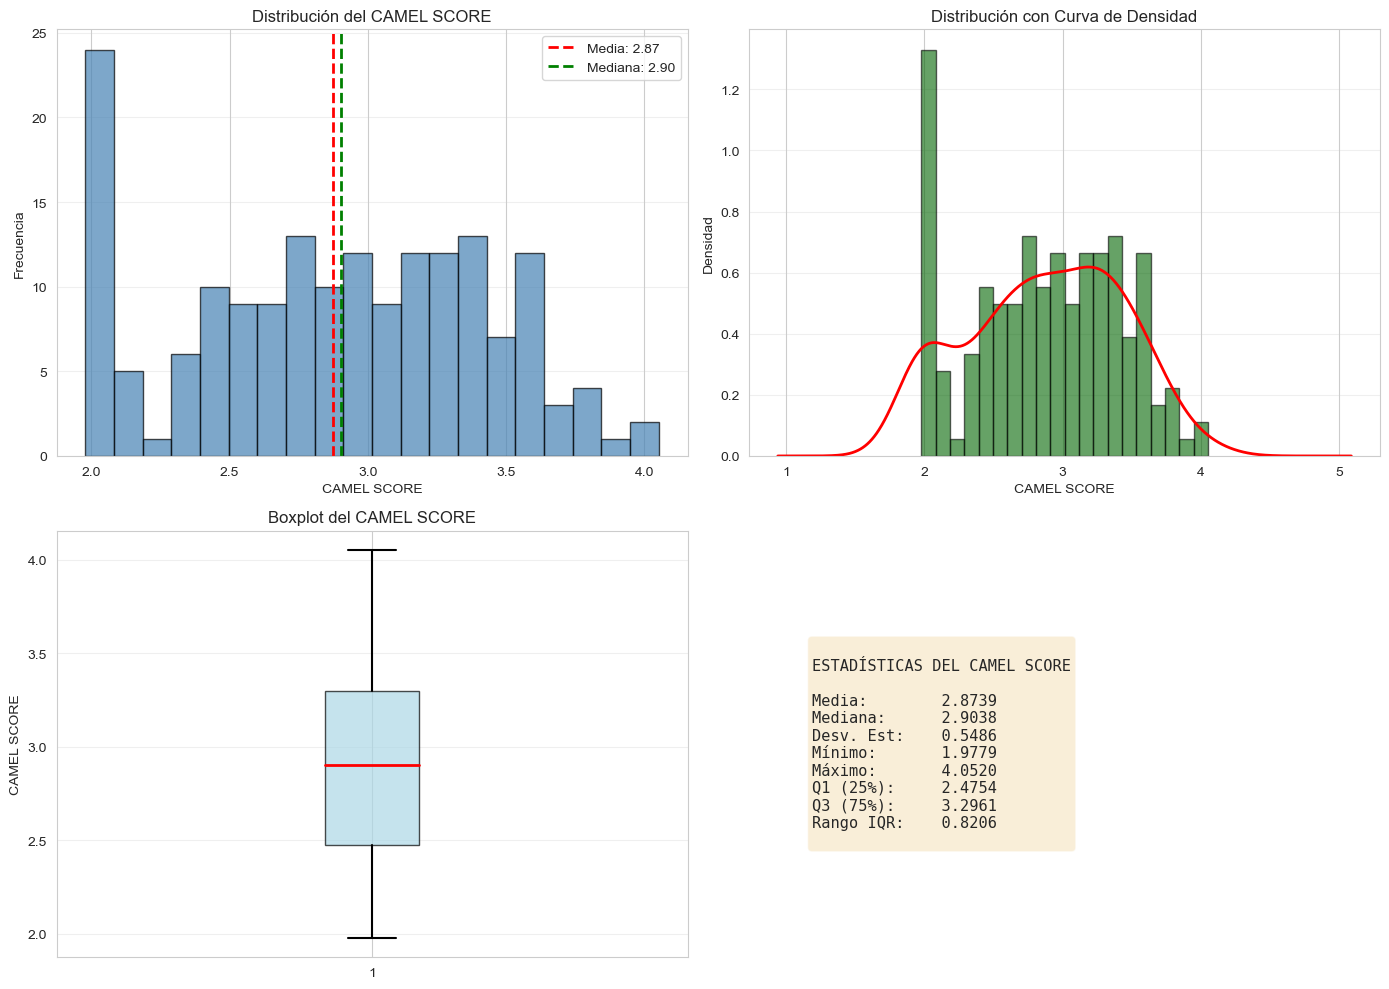

In [19]:
camel_ultimo=camel_definitivo.copy()
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style("whitegrid")

# Crear figura con múltiples visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histograma simple
axes[0, 0].hist(camel_ultimo['CAMEL_score'], bins=20, edgecolor='black', color='steelblue', alpha=0.7)
axes[0, 0].axvline(camel_ultimo['CAMEL_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {camel_ultimo["CAMEL_score"].mean():.2f}')
axes[0, 0].axvline(camel_ultimo['CAMEL_score'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {camel_ultimo["CAMEL_score"].median():.2f}')
axes[0, 0].set_xlabel('CAMEL SCORE')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución del CAMEL SCORE')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Histograma con KDE
axes[0, 1].hist(camel_ultimo['CAMEL_score'], bins=20, edgecolor='black', color='darkgreen', alpha=0.6, density=True)
camel_ultimo['CAMEL_score'].plot(kind='kde', ax=axes[0, 1], color='red', linewidth=2)
axes[0, 1].set_xlabel('CAMEL SCORE')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].set_title('Distribución con Curva de Densidad')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Boxplot
axes[1, 0].boxplot(camel_ultimo['CAMEL_score'], vert=True, patch_artist=True, 
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5))
axes[1, 0].set_ylabel('CAMEL SCORE')
axes[1, 0].set_title('Boxplot del CAMEL SCORE')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Estadísticas resumidas
stats_text = f"""
ESTADÍSTICAS DEL CAMEL SCORE

Media:        {camel_ultimo['CAMEL_score'].mean():.4f}
Mediana:      {camel_ultimo['CAMEL_score'].median():.4f}
Desv. Est:    {camel_ultimo['CAMEL_score'].std():.4f}
Mínimo:       {camel_ultimo['CAMEL_score'].min():.4f}
Máximo:       {camel_ultimo['CAMEL_score'].max():.4f}
Q1 (25%):     {camel_ultimo['CAMEL_score'].quantile(0.25):.4f}
Q3 (75%):     {camel_ultimo['CAMEL_score'].quantile(0.75):.4f}
Rango IQR:    {camel_ultimo['CAMEL_score'].quantile(0.75) - camel_ultimo['CAMEL_score'].quantile(0.25):.4f}
"""
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center', 
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()



In [20]:
import pandas as pd


def ejecutar_modelo_camel(df):
    """
    Ejecuta el modelo CAMEL para General y para cada categoría.

    Retorna un DataFrame con:
        ID_cooperativa
        CAMEL_score
        categoria
    """

    if df.empty:
        raise ValueError("El DataFrame está vacío")

    resultados_camel = []

    # ==========================================================
    # GENERAL
    # ==========================================================

    df_general = df.copy()

    lista_coops = (
        df_general["ID_cooperativa"]
        .dropna()
        .unique()
        .tolist()
    )

    # 1. Pesos PCA
    pesos = pesos_pca_grupo_coops(
        df_general,
        lista_coops
    )

    # 2. Calificaciones
    calificaciones = calcular_calificaciones_formato_lista(
        df_general
    )

    # 3. CAMEL
    camel = calcular_camel(
        calificaciones,
        pesos
    )

    # Agregar categoría General
    camel["categoria"] = "General"

    resultados_camel.append(camel)


    # ==========================================================
    # CATEGORÍAS
    # ==========================================================

    categorias = (
        df["categoria"]
        .dropna()
        .unique()
    )

    for categoria in categorias:

        df_categoria = df[
            df["categoria"] == categoria
        ].copy()

        lista_coops = (
            df_categoria["ID_cooperativa"]
            .dropna()
            .unique()
            .tolist()
        )

        # 1. Pesos PCA
        pesos = pesos_pca_grupo_coops(
            df_categoria,
            lista_coops
        )

        # 2. Calificaciones
        calificaciones = calcular_calificaciones_formato_lista(
            df_categoria
        )

        # 3. CAMEL
        camel = calcular_camel(
            calificaciones,
            pesos
        )

        # Agregar categoría
        camel["categoria"] = categoria

        resultados_camel.append(camel)


    # ==========================================================
    # UNIR TODOS LOS RESULTADOS
    # ==========================================================

    resultado_final = pd.concat(
        resultados_camel,
        ignore_index=True
    )

    # Asegurar exactamente las columnas solicitadas
    resultado_final = resultado_final[
        [
            "ID_cooperativa",
            "CAMEL_score",
            "categoria"
        ]
    ]

    return resultado_final

resultado=ejecutar_modelo_camel(datos)

In [21]:
resultado.to_excel("resultado_camel.xlsx", index=False)

# 5. Cálculo modelo CAMEL - sectorizado

Además, generar gráficos estadísticos para los resultados tanto categorizados como generales, que sirvan para complementar el análisis de los resultados.

In [22]:
datos["categoria"].unique()

array(['Micro 1', 'Medianas', 'Megas', 'Pequeñas', 'Grandes', 'Micro 2'],
      dtype=object)

In [23]:
import pandas as pd

# ============================================
# CATEGORÍAS
# ============================================

categorias = [
    "Megas",
    "Grandes",
    "Medianas",
    "Pequeñas",
    "Micro 1",
    "Micro 2"
]

# ============================================
# ARCHIVO EXCEL
# ============================================

nombre_excel = "../../tablas/percentiles_y_rangos/percentiles_indicadores_categorizados.xlsx"

with pd.ExcelWriter(nombre_excel, engine="openpyxl") as writer:

    for categoria in categorias:

        # Filtrar datos
        datos_categoria = datos.loc[
            datos["categoria"] == categoria
        ]

        # Calcular percentiles
        df, percentiles = calificar_dataframe(
            datos_categoria
        )

        # Convertir a DataFrame
        percentiles_df = pd.DataFrame(
            percentiles
        ).T

        # Guardar en hoja con nombre de categoría
        percentiles_df.to_excel(
            writer,
            sheet_name=categoria[:31],  # límite Excel
            index=True
        )

print("Archivo Excel generado correctamente.")


Archivo Excel generado correctamente.


In [24]:
import pandas as pd

# ============================================
# CATEGORÍAS
# ============================================

categorias = [
    "Megas",
    "Grandes",
    "Medianas",
    "Pequeñas",
    "Micro 1",
    "Micro 2"
]

# ============================================
# ARCHIVO EXCEL
# ============================================

nombre_excel = "../../tablas/percentiles_y_rangos/PCA_indicadores_categorizados.xlsx"

with pd.ExcelWriter(nombre_excel, engine="openpyxl") as writer:

    for categoria in categorias:

        # ============================================
        # FILTRAR DATOS
        # ============================================

        datos_categoria = datos.loc[
            datos["categoria"] == categoria
        ]

        # ============================================
        # LISTA DE COOPERATIVAS
        # ============================================

        lista_coops = datos_categoria[
            "ID_cooperativa"
        ].unique().tolist()

        # ============================================
        # CALCULAR PCA
        # ============================================

        pca = pesos_pca_grupo_coops(
            datos_categoria,
            lista_coops=lista_coops,
            col_nombre="ID_cooperativa",
            n_componentes=3
        )

        # ============================================
        # PASAR A PORCENTAJE
        # ============================================

        pca_porcentaje = pca * 100

        # ============================================
        # CONVERTIR A DATAFRAME
        # ============================================

        if isinstance(pca_porcentaje, pd.Series):
            pca_df = pca_porcentaje.to_frame(
                name="peso_porcentaje"
            )
        else:
            pca_df = pd.DataFrame(pca_porcentaje)

        # ============================================
        # GUARDAR EN EXCEL
        # ============================================

        pca_df.to_excel(
            writer,
            sheet_name=categoria[:31],
            index=True
        )

print("Archivo Excel generado correctamente.")


Archivo Excel generado correctamente.


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook
from openpyxl.drawing.image import Image

# ============================================
# ARCHIVO DE SALIDA
# ============================================

nombre_excel = "../../tablas/camel/resultado_CAMEL/resultado_camel_categorizado.xlsx"

# Crear writer
with pd.ExcelWriter(nombre_excel, engine="openpyxl") as writer:

    coperativas = ['Micro 1', 'Medianas', 'Megas',
                   'Pequeñas', 'Grandes', 'Micro 2']

    for coperativa in coperativas:

        # ============================================
        # FILTRAR DATOS
        # ============================================

        datos_categoria = datos.loc[
            datos["categoria"] == coperativa
        ]

        lista_coops = datos_categoria[
            "ID_cooperativa"
        ].unique().tolist()

        # ============================================
        # CALCULAR PCA Y CAMEL
        # ============================================

        pca_ = pesos_pca_grupo_coops(
            datos_categoria,
            lista_coops=lista_coops,
            col_nombre="ID_cooperativa",
            n_componentes=3
        )

        calificaciones_ = calcular_calificaciones_formato_lista(
            datos_categoria
        )

        camel_definitivo = calcular_camel(
            calificaciones_,
            pca_
        )

        camel_ultimo = camel_definitivo.copy()

        # ============================================
        # GUARDAR TABLA EN EXCEL
        # ============================================

        nombre_hoja = coperativa[:31]  # Excel limita nombres

        camel_ultimo.to_excel(
            writer,
            sheet_name=nombre_hoja,
            index=False
        )

        # ============================================
        # CREAR GRAFICAS
        # ============================================

        sns.set_style("whitegrid")

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Histograma
        axes[0, 0].hist(
            camel_ultimo['CAMEL_score'],
            bins=20,
            edgecolor='black',
            color='steelblue',
            alpha=0.7
        )

        axes[0, 0].axvline(
            camel_ultimo['CAMEL_score'].mean(),
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Media: {camel_ultimo["CAMEL_score"].mean():.2f}'
        )

        axes[0, 0].axvline(
            camel_ultimo['CAMEL_score'].median(),
            color='green',
            linestyle='--',
            linewidth=2,
            label=f'Mediana: {camel_ultimo["CAMEL_score"].median():.2f}'
        )

        axes[0, 0].set_title('Distribución CAMEL')
        axes[0, 0].legend()

        # KDE
        axes[0, 1].hist(
            camel_ultimo['CAMEL_score'],
            bins=20,
            density=True,
            alpha=0.6
        )

        camel_ultimo['CAMEL_score'].plot(
            kind='kde',
            ax=axes[0, 1]
        )

        axes[0, 1].set_title('Densidad')

        # Boxplot
        axes[1, 0].boxplot(
            camel_ultimo['CAMEL_score'],
            vert=True,
            patch_artist=True
        )

        axes[1, 0].set_title('Boxplot')

        # Estadísticas
        stats_text = f"""
Media:      {camel_ultimo['CAMEL_score'].mean():.4f}
Mediana:    {camel_ultimo['CAMEL_score'].median():.4f}
Std:        {camel_ultimo['CAMEL_score'].std():.4f}
Min:        {camel_ultimo['CAMEL_score'].min():.4f}
Max:        {camel_ultimo['CAMEL_score'].max():.4f}
"""

        axes[1, 1].text(
            0.1,
            0.5,
            stats_text,
            fontsize=11
        )

        axes[1, 1].axis('off')

        plt.tight_layout()

        # ============================================
        # GUARDAR IMAGEN TEMPORAL
        # ============================================
        nombre_imagen = f"../../tablas/camel/resultado_CAMEL/estadísticas/{coperativa}_estadisticas.png"

        plt.savefig(nombre_imagen, dpi=300)
        plt.close()

# ============================================
# INSERTAR IMAGENES EN EXCEL
# ============================================

wb = load_workbook(nombre_excel)

for coperativa in coperativas:

    nombre_hoja = coperativa[:31]

    ws = wb[nombre_hoja]

    img = Image(f"../../tablas/camel/resultado_CAMEL/estadísticas/{coperativa}_estadisticas.png")

    # Posición donde aparecerá la imagen
    ws.add_image(img, "H2")

# Guardar cambios finales
wb.save(nombre_excel)

print("Excel generado correctamente.")

Excel generado correctamente.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook
from openpyxl.drawing.image import Image

# ============================================
# CALCULAR CAMEL GENERAL (SIN SEGMENTACIÓN)
# ============================================

lista_coops = datos["ID_cooperativa"].unique().tolist()

pca_ = pesos_pca_grupo_coops(
    datos,
    lista_coops=lista_coops,
    col_nombre="ID_cooperativa",
    n_componentes=3
)

calificaciones_ = calcular_calificaciones_formato_lista(
    datos
)

camel_definitivo = calcular_camel(
    calificaciones_,
    pca_
)

camel_ultimo = camel_definitivo.copy()

# ============================================
# NOMBRE ARCHIVO
# ============================================

nombre_excel = "../../tablas/camel/resultado_CAMEL/resultado_camel_general.xlsx"

# ============================================
# GUARDAR DATAFRAME EN EXCEL
# ============================================

with pd.ExcelWriter(nombre_excel, engine="openpyxl") as writer:

    camel_ultimo.to_excel(
        writer,
        sheet_name="CAMEL_GENERAL",
        index=False
    )

# ============================================
# CREAR GRÁFICAS
# ============================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histograma
axes[0, 0].hist(
    camel_ultimo['CAMEL_score'],
    bins=20,
    edgecolor='black',
    color='steelblue',
    alpha=0.7
)

axes[0, 0].axvline(
    camel_ultimo['CAMEL_score'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Media: {camel_ultimo["CAMEL_score"].mean():.2f}'
)

axes[0, 0].axvline(
    camel_ultimo['CAMEL_score'].median(),
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Mediana: {camel_ultimo["CAMEL_score"].median():.2f}'
)

axes[0, 0].set_xlabel('CAMEL SCORE')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución del CAMEL SCORE')
axes[0, 0].legend()

# 2. Histograma con KDE
axes[0, 1].hist(
    camel_ultimo['CAMEL_score'],
    bins=20,
    density=True,
    edgecolor='black',
    alpha=0.6
)

camel_ultimo['CAMEL_score'].plot(
    kind='kde',
    ax=axes[0, 1],
    linewidth=2
)

axes[0, 1].set_title('Distribución con KDE')

# 3. Boxplot
axes[1, 0].boxplot(
    camel_ultimo['CAMEL_score'],
    vert=True,
    patch_artist=True
)

axes[1, 0].set_title('Boxplot CAMEL')

# 4. Estadísticas
stats_text = f"""
ESTADÍSTICAS

Media:      {camel_ultimo['CAMEL_score'].mean():.4f}
Mediana:    {camel_ultimo['CAMEL_score'].median():.4f}
Std:        {camel_ultimo['CAMEL_score'].std():.4f}
Min:        {camel_ultimo['CAMEL_score'].min():.4f}
Max:        {camel_ultimo['CAMEL_score'].max():.4f}

Q1:         {camel_ultimo['CAMEL_score'].quantile(0.25):.4f}
Q3:         {camel_ultimo['CAMEL_score'].quantile(0.75):.4f}
"""

axes[1, 1].text(
    0.1,
    0.5,
    stats_text,
    fontsize=11,
    family='monospace'
)

axes[1, 1].axis('off')

plt.tight_layout()

# ============================================
# GUARDAR IMAGEN
# ============================================

nombre_imagen = "../../tablas/camel/resultado_CAMEL/estadísticas/camel_general.png"

plt.savefig(nombre_imagen, dpi=300)
plt.close()

# ============================================
# INSERTAR IMAGEN EN EXCEL
# ============================================

wb = load_workbook(nombre_excel)

ws = wb["CAMEL_GENERAL"]

img = Image(nombre_imagen)

# Ajustar tamaño opcional
img.width = 900
img.height = 600

# Posición en la hoja
ws.add_image(img, "H2")

# Guardar
wb.save(nombre_excel)

print("Excel generado correctamente.")

Excel generado correctamente.
